# Tratamiento de NaN y construcciones de perfiles nocturnos

Dataset A - Casos completos

Dataset B - Imputación simple - Mediana

Dataset C - Imputación avanzada - KNN Imputer



In [1]:
# Cargamos librerías

import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Vamos a cargar el Dataset Maestro

df= pd.read_csv(r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\perfiles_limpios_2022_2024_15000_80000.csv", 
                 encoding= "ISO-8859-1")

print(df.shape)
df.head()

(11041, 653)


,archivo,fecha,time,15068,15168,15268,15368,15468,15568,15668,...,79068,79168,79268,79368,79468,79568,79668,79768,79868,79968
0,20220102-0204_T60Z900,2022-01-02,10110000,224.12709,224.06079,224.03088,224.00032,224.00107,223.97531,223.91777,...,180.91070,180.95862,181.18726,181.34350,181.20433,180.83385,180.34563,179.80880,178.84262,178.01134
1,20220102-0204_T60Z900,2022-01-02,11010000,224.15086,224.08093,224.04492,224.00494,223.99844,223.96309,223.89388,...,180.91070,180.95862,181.18726,181.34350,181.20433,180.83385,180.34563,179.80880,178.84262,178.01134
2,20220102-0204_T60Z900,2022-01-02,11910000,223.87470,223.81165,223.79224,223.75688,223.75171,223.71470,223.63731,...,181.23099,181.10963,181.09753,181.08950,180.91277,180.51624,179.91145,179.32465,178.46750,177.62988
3,20220102-0204_T60Z900,2022-01-02,14610000,225.60756,225.46303,225.28813,225.04552,224.78656,224.51508,224.26501,...,172.72400,172.50027,172.08762,172.05359,172.00668,172.09430,172.22276,172.71014,172.93466,173.25317
4,20220102-0204_T60Z900,2022-01-02,15510000,225.51476,225.39750,225.27725,225.07066,224.84776,224.61030,224.36234,...,173.40164,173.50017,173.40290,173.55354,173.68790,173.85191,174.02992,174.31717,174.40381,174.74709


In [3]:
# Vamos a separar las variables descriptivas de las atmosféricas

meta_cols = ["archivo", "fecha", "time"]

X_meta = df[meta_cols].copy()
X_temp = df.drop(columns=meta_cols).copy()

print(X_meta.shape)
print(X_temp.shape)

(11041, 3)
(11041, 650)


In [4]:
# Vamos a verificar punto inicial de NaN

perfiles_con_nan = X_temp.isna().any(axis=1).sum()

print(f"Perfiles sin NaN: {len(X_temp)-perfiles_con_nan}")
print(f"Perfiles con NaN: {perfiles_con_nan}")
print(f"Porcentaje: {100*perfiles_con_nan/len(X_temp):.2f}%")

nan_totales = X_temp.isna().sum().sum()

print(f"NaN totales: {nan_totales:,}")


Perfiles sin NaN: 8541
Perfiles con NaN: 2500
Porcentaje: 22.64%
NaN totales: 358,154


## Hasta este momento confirmamos que estamos en el punto final de la etapa anterior

In [5]:
# Vamos a armar el Dataset A

mask_completos = ~X_temp.isna().any(axis=1)

df_A = pd.concat(
    [
        X_meta.loc[mask_completos],
        X_temp.loc[mask_completos]
    ],
    axis=1)

print(df_A.shape)

df_A.to_csv(
    "dataset_A_casos_completos.csv",
    index=False)
print("Archivo guardado.")


(8541, 653)
Archivo guardado.


In [6]:
# Vamos a armar el Dataset B
# Vamos a imputar por mediana

medianas = X_temp.median()
X_temp_B = X_temp.fillna(medianas)

df_B = pd.concat(
    [
        X_meta,
        X_temp_B
    ],
    axis=1)

In [7]:
# Verificamos que no hayan quedado NaN
print(X_temp_B.isna().sum().sum())

0


In [8]:
df_B.to_csv(
    "dataset_B_mediana.csv",
    index=False)

print(df_B.shape)

df_B.to_csv(
    "dataset_B_mediana.csv",
    index=False
)
print("Archivo guardado.")

(11041, 653)
Archivo guardado.


In [9]:
# Vamos a armar el Dataset C
# Vamos a imputar por KNN Imputer

KNNImputer(
    n_neighbors=5,
    weights="distance")

imputer = KNNImputer(
    n_neighbors=5,
    weights="distance")

X_temp_C = pd.DataFrame(
    imputer.fit_transform(X_temp),
    columns=X_temp.columns,
    index=X_temp.index)

df_C = pd.concat(
    [
        X_meta,
        X_temp_C
    ],
    axis=1)

print("done")

done


In [10]:
# Verificamos que no hayan quedado NaN

print(X_temp_C.isna().sum().sum())

0


In [11]:
print(df_C.shape)

df_C.to_csv(
    "dataset_C_knn.csv",
    index=False)

print("Archivo guardado.")

(11041, 653)
Archivo guardado.


In [12]:
df_C.head()

,archivo,fecha,time,15068,15168,15268,15368,15468,15568,15668,...,79068,79168,79268,79368,79468,79568,79668,79768,79868,79968
0,20220102-0204_T60Z900,2022-01-02,10110000,224.12709,224.06079,224.03088,224.00032,224.00107,223.97531,223.91777,...,180.91070,180.95862,181.18726,181.34350,181.20433,180.83385,180.34563,179.80880,178.84262,178.01134
1,20220102-0204_T60Z900,2022-01-02,11010000,224.15086,224.08093,224.04492,224.00494,223.99844,223.96309,223.89388,...,180.91070,180.95862,181.18726,181.34350,181.20433,180.83385,180.34563,179.80880,178.84262,178.01134
2,20220102-0204_T60Z900,2022-01-02,11910000,223.87470,223.81165,223.79224,223.75688,223.75171,223.71470,223.63731,...,181.23099,181.10963,181.09753,181.08950,180.91277,180.51624,179.91145,179.32465,178.46750,177.62988
3,20220102-0204_T60Z900,2022-01-02,14610000,225.60756,225.46303,225.28813,225.04552,224.78656,224.51508,224.26501,...,172.72400,172.50027,172.08762,172.05359,172.00668,172.09430,172.22276,172.71014,172.93466,173.25317
4,20220102-0204_T60Z900,2022-01-02,15510000,225.51476,225.39750,225.27725,225.07066,224.84776,224.61030,224.36234,...,173.40164,173.50017,173.40290,173.55354,173.68790,173.85191,174.02992,174.31717,174.40381,174.74709


In [13]:
# Vamos a armar una tabla resumen

resumen = pd.DataFrame({
    "Dataset": [
        "Original",
        "A",
        "B",
        "C"
    ],
    "Perfiles": [
        len(df),
        len(df_A),
        len(df_B),
        len(df_C)
    ],
    "NaN": [
        X_temp.isna().sum().sum(),
        df_A.drop(columns=meta_cols).isna().sum().sum(),
        df_B.drop(columns=meta_cols).isna().sum().sum(),
        df_C.drop(columns=meta_cols).isna().sum().sum()
    ]
})

resumen

,Dataset,Perfiles,NaN
0,Original,11041,358154
1,A,8541,0
2,B,11041,0
3,C,11041,0


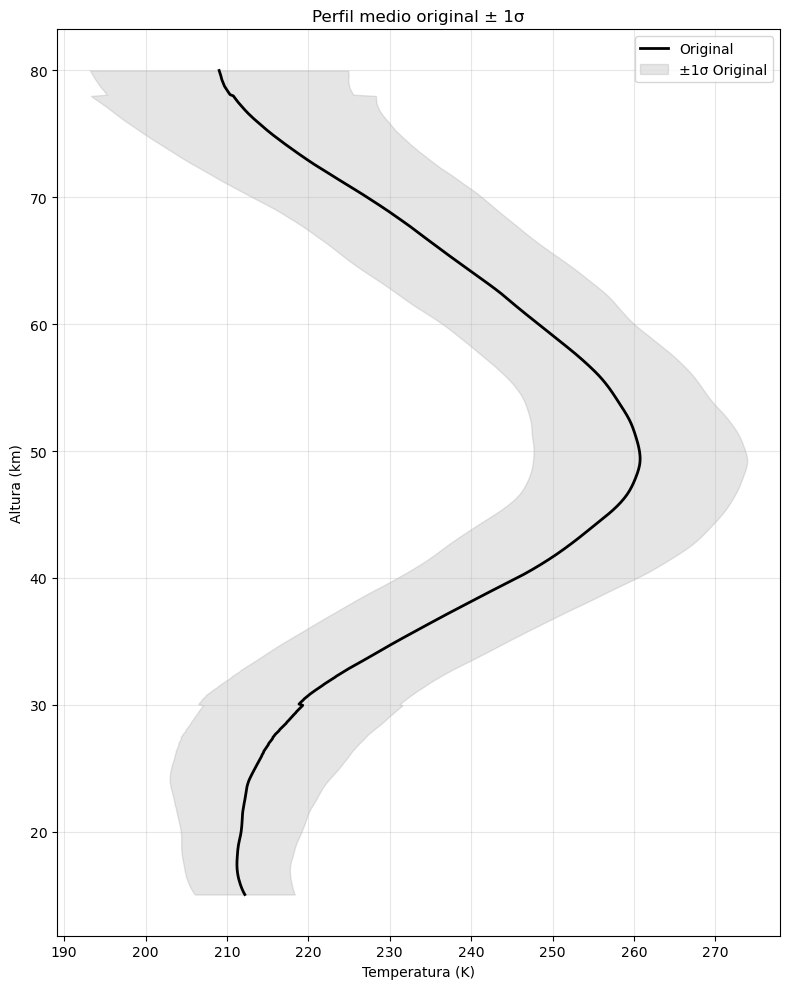

In [14]:
# Vamos a graficar

perfil_original = X_temp.mean()
std_original = X_temp.std()

alturas_km = X_temp.columns.astype(float) / 1000

plt.figure(figsize=(8,10))

plt.plot(
    perfil_original,
    alturas_km,
    color='black',
    linewidth=2,
    label='Original'
)

plt.fill_betweenx(
    alturas_km,
    perfil_original - std_original,
    perfil_original + std_original,
    alpha=0.2,
    color='gray',
    label='±1σ Original'
)

plt.xlabel('Temperatura (K)')
plt.ylabel('Altura (km)')
plt.title('Perfil medio original ± 1σ')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


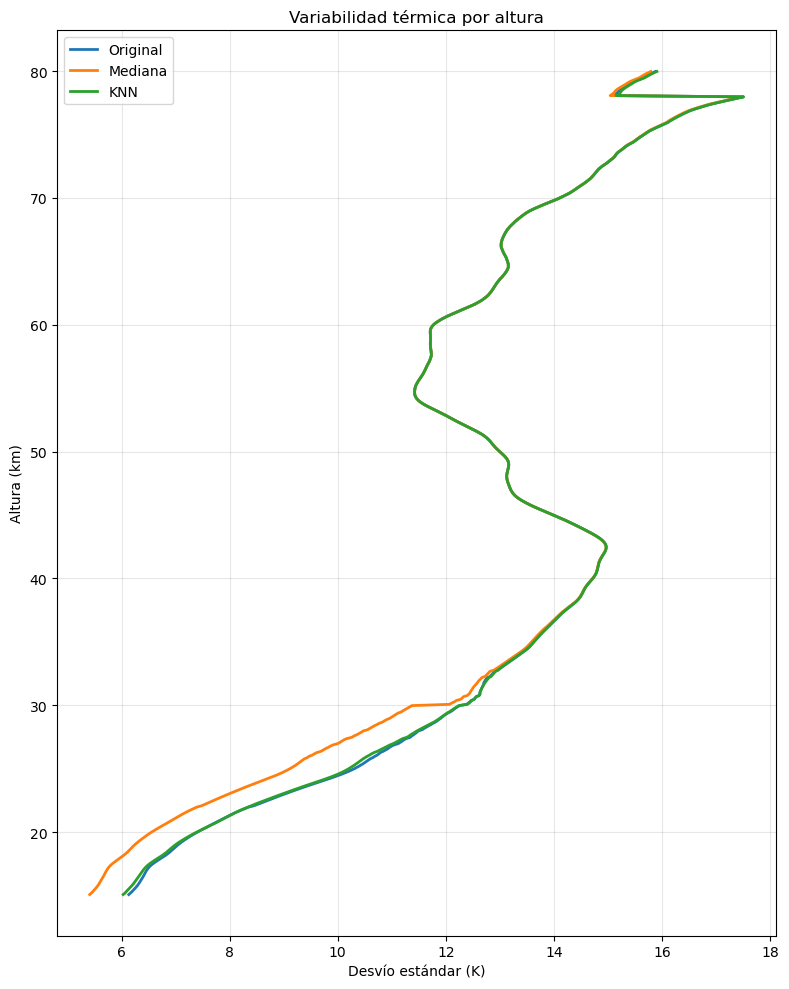

In [15]:
std_original = X_temp.std()
std_B = X_temp_B.std()
std_C = X_temp_C.std()

plt.figure(figsize=(8,10))

plt.plot(
    std_original,
    alturas_km,
    label='Original',
    linewidth=2
)

plt.plot(
    std_B,
    alturas_km,
    label='Mediana',
    linewidth=2
)

plt.plot(
    std_C,
    alturas_km,
    label='KNN',
    linewidth=2
)

plt.xlabel('Desvío estándar (K)')
plt.ylabel('Altura (km)')
plt.title('Variabilidad térmica por altura')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

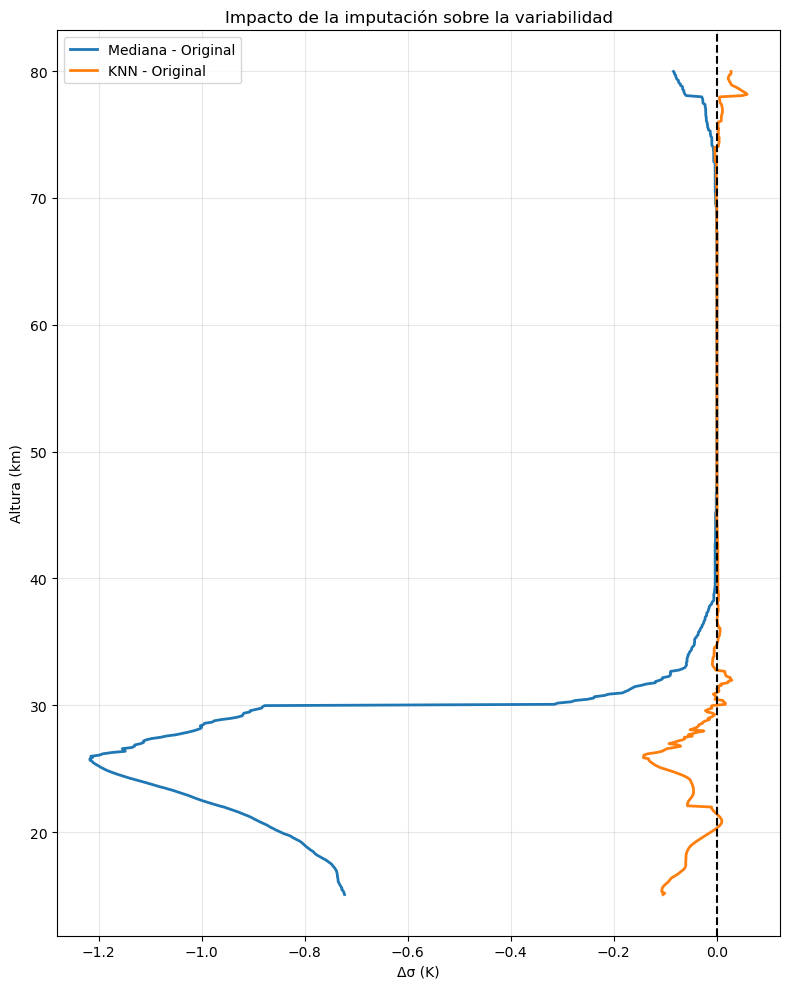

In [16]:
diff_std_B = std_B - std_original
diff_std_C = std_C - std_original

plt.figure(figsize=(8,10))

plt.plot(
    diff_std_B,
    alturas_km,
    label='Mediana - Original',
    linewidth=2
)

plt.plot(
    diff_std_C,
    alturas_km,
    label='KNN - Original',
    linewidth=2
)

plt.axvline(
    0,
    color='black',
    linestyle='--'
)

plt.xlabel('Δσ (K)')
plt.ylabel('Altura (km)')
plt.title('Impacto de la imputación sobre la variabilidad')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

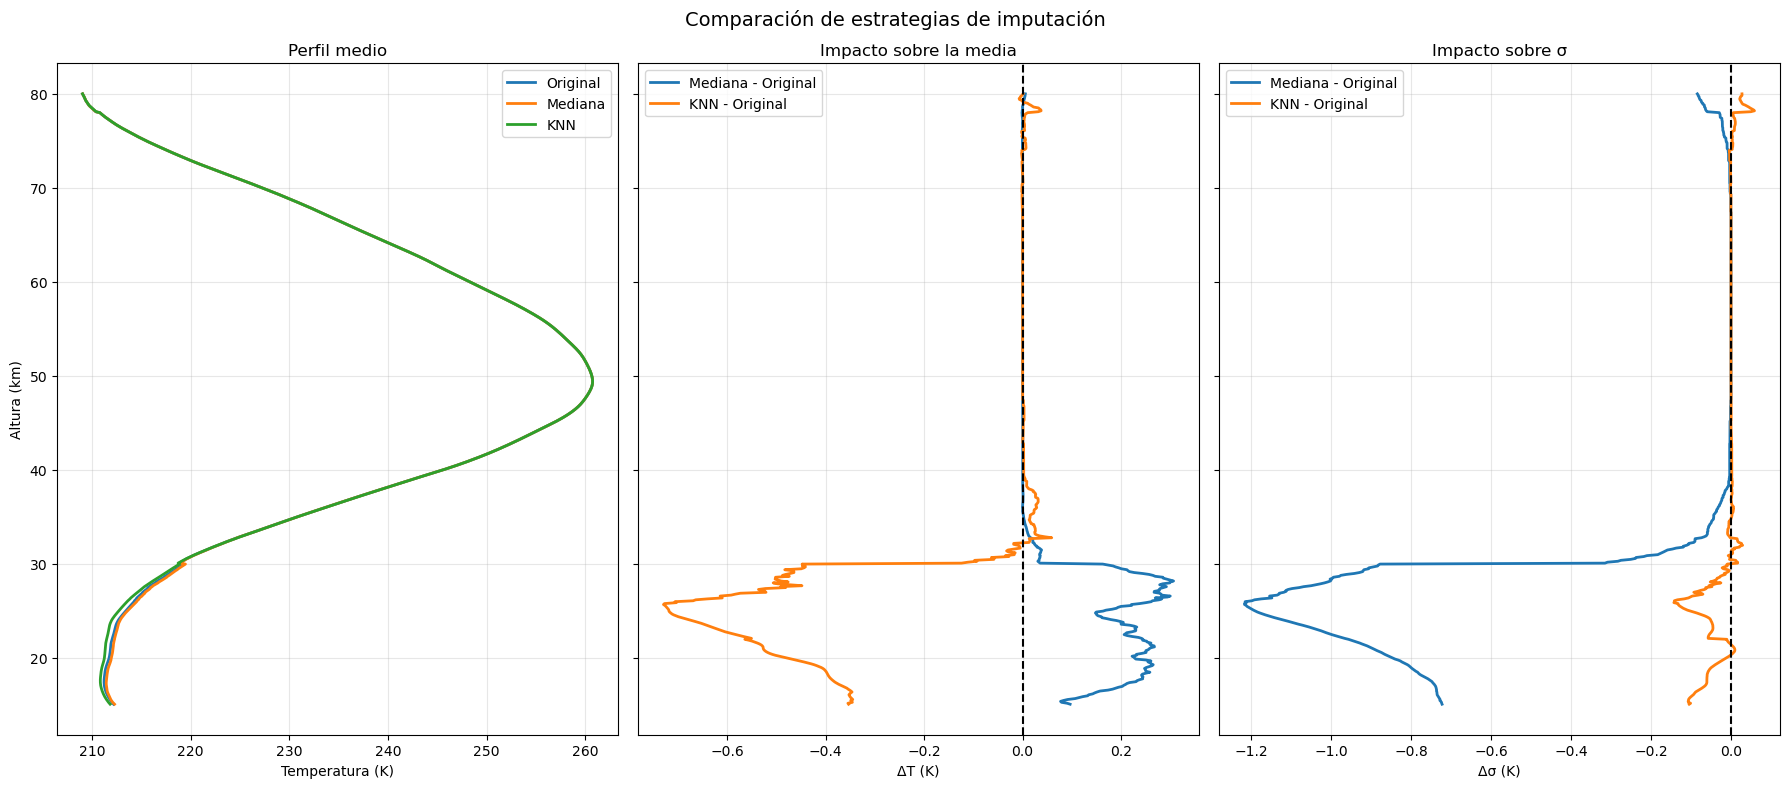

In [17]:
# Los tres gráficos en uno

# ============================
# Estadísticos
# ============================

alturas_km = X_temp.columns.astype(float) / 1000

perfil_original = X_temp.mean()
perfil_B = X_temp_B.mean()
perfil_C = X_temp_C.mean()

std_original = X_temp.std()
std_B = X_temp_B.std()
std_C = X_temp_C.std()

diff_media_B = perfil_B - perfil_original
diff_media_C = perfil_C - perfil_original

diff_std_B = std_B - std_original
diff_std_C = std_C - std_original

# ============================
# Figura
# ============================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    sharey=True
)

# =====================================
# Gráfico 1 - Perfil medio
# =====================================

axes[0].plot(
    perfil_original,
    alturas_km,
    label='Original',
    linewidth=2
)

axes[0].plot(
    perfil_B,
    alturas_km,
    label='Mediana',
    linewidth=2
)

axes[0].plot(
    perfil_C,
    alturas_km,
    label='KNN',
    linewidth=2
)

axes[0].set_title('Perfil medio')
axes[0].set_xlabel('Temperatura (K)')
axes[0].set_ylabel('Altura (km)')
axes[0].grid(alpha=0.3)
axes[0].legend()

# =====================================
# Gráfico 2 - Diferencia de medias
# =====================================

axes[1].plot(
    diff_media_B,
    alturas_km,
    label='Mediana - Original',
    linewidth=2
)

axes[1].plot(
    diff_media_C,
    alturas_km,
    label='KNN - Original',
    linewidth=2
)

axes[1].axvline(
    0,
    color='black',
    linestyle='--'
)

axes[1].set_title('Impacto sobre la media')
axes[1].set_xlabel('ΔT (K)')
axes[1].grid(alpha=0.3)
axes[1].legend()

# =====================================
# Gráfico 3 - Diferencia de desvío
# =====================================

axes[2].plot(
    diff_std_B,
    alturas_km,
    label='Mediana - Original',
    linewidth=2
)

axes[2].plot(
    diff_std_C,
    alturas_km,
    label='KNN - Original',
    linewidth=2
)

axes[2].axvline(
    0,
    color='black',
    linestyle='--'
)

axes[2].set_title('Impacto sobre σ')
axes[2].set_xlabel('Δσ (K)')
axes[2].grid(alpha=0.3)
axes[2].legend()

# =====================================

plt.suptitle(
    'Comparación de estrategias de imputación',
    fontsize=14
)

plt.tight_layout()
plt.show()

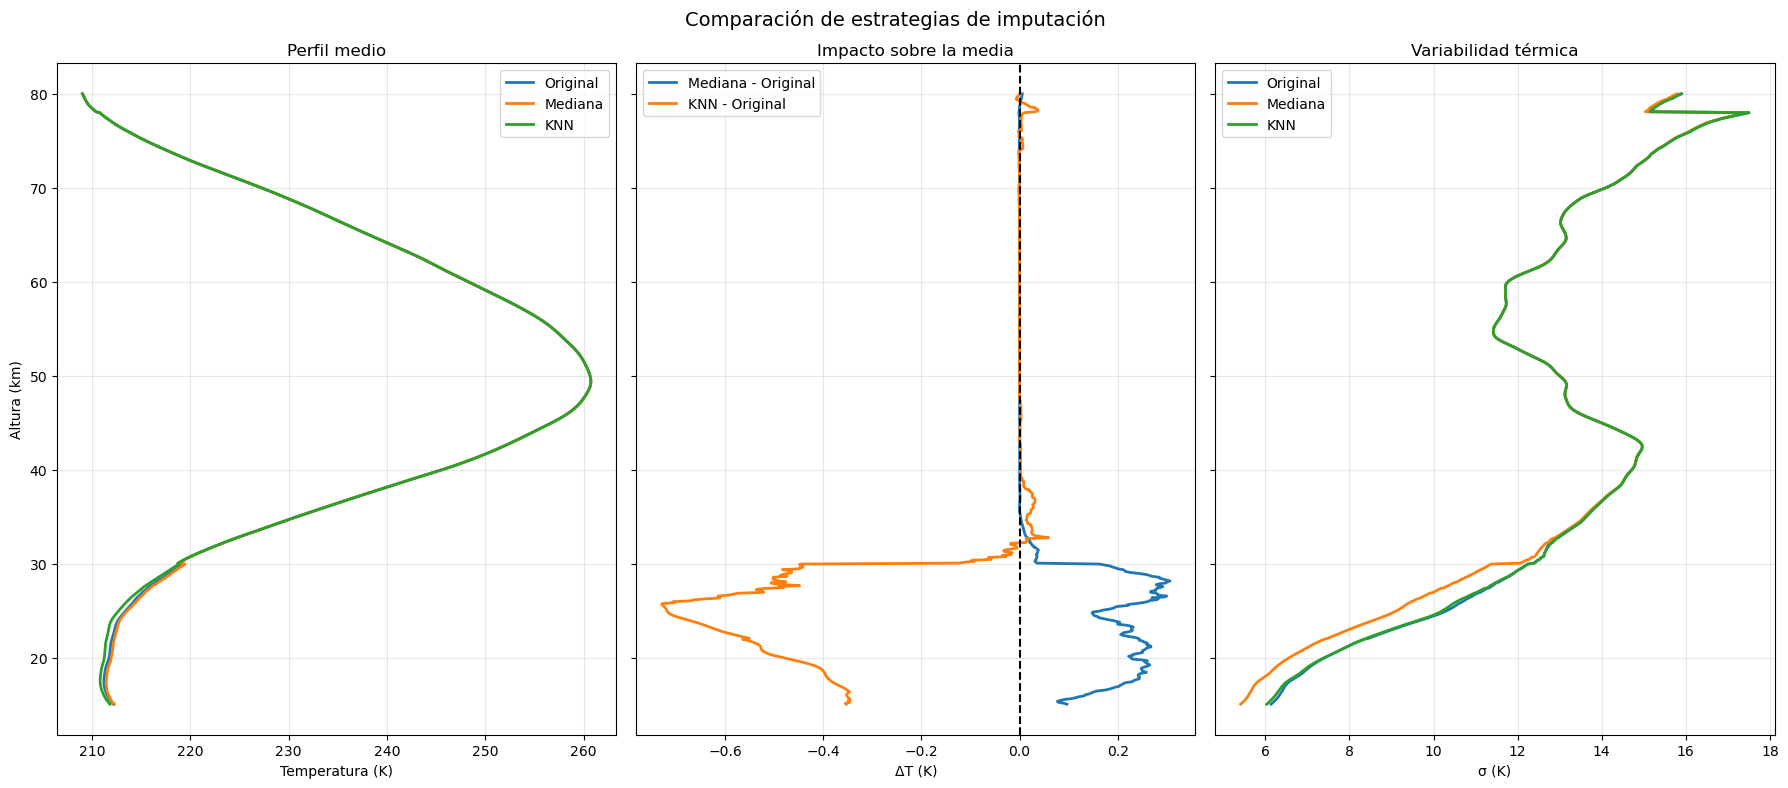

In [18]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    sharey=True
)

# =====================================
# Gráfico 1 - Perfil medio
# =====================================

axes[0].plot(perfil_original, alturas_km,
             label='Original', linewidth=2)

axes[0].plot(perfil_B, alturas_km,
             label='Mediana', linewidth=2)

axes[0].plot(perfil_C, alturas_km,
             label='KNN', linewidth=2)

axes[0].set_title('Perfil medio')
axes[0].set_xlabel('Temperatura (K)')
axes[0].set_ylabel('Altura (km)')
axes[0].grid(alpha=0.3)
axes[0].legend()

# =====================================
# Gráfico 2 - Diferencia de medias
# =====================================

axes[1].plot(diff_media_B, alturas_km,
             label='Mediana - Original',
             linewidth=2)

axes[1].plot(diff_media_C, alturas_km,
             label='KNN - Original',
             linewidth=2)

axes[1].axvline(0,
                color='black',
                linestyle='--')

axes[1].set_title('Impacto sobre la media')
axes[1].set_xlabel('ΔT (K)')
axes[1].grid(alpha=0.3)
axes[1].legend()

# =====================================
# Gráfico 3 - Variabilidad térmica
# =====================================

axes[2].plot(std_original, alturas_km,
             label='Original',
             linewidth=2)

axes[2].plot(std_B, alturas_km,
             label='Mediana',
             linewidth=2)

axes[2].plot(std_C, alturas_km,
             label='KNN',
             linewidth=2)

axes[2].set_title('Variabilidad térmica')
axes[2].set_xlabel('σ (K)')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle(
    'Comparación de estrategias de imputación',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Conclusiones

### Perfil medio

La imputación por KNN (I. KNN) reproduce casi exactamente el perfil medio original.
La imputación por mediana (I. Mediana) introduce pequeñas diferencias en el intervalo 15-30 km (que es donde se concentran los NaN)

### Impacto sobre la media

I. Mediana - Original
Llega a ΔT ≈ +0,25 K en el intervalo 15-30 km

I. KNN - Original
Llega a ΔT ≈ −0,7 K en el intervalo 15-30 km

De todas maneras, respecto a las temperaturas del intervalo T ≈ 215 K, no hay diferencia significativa < 0.5%

### Variabilidad Térmica

I. Mediana
Reduce la variabilidad en el intervalo 15-30 km

I. KNN
Preserva la variabilidad original de los perfiles

## Conclusion

La Imputación por KNN parece ser el candidato más robusto, ya que reproduce el perfil medio original y preserva la variabilidad original de los perfiles.


In [19]:
# Algunos datos concretos sobre las diferencias
print(
    "Máxima diferencia media - Mediana:",
    np.abs(diff_media_B).max()
)

print(
    "Máxima diferencia media - KNN:",
    np.abs(diff_media_C).max()
)
print(
    "Máxima diferencia σ - Mediana:",
    np.abs(std_B - std_original).max()
)

print(
    "Máxima diferencia σ - KNN:",
    np.abs(std_C - std_original).max()
)

Máxima diferencia media - Mediana: 0.30648869096339126
Máxima diferencia media - KNN: 0.7293215630203917
Máxima diferencia σ - Mediana: 1.2172916390231734
Máxima diferencia σ - KNN: 0.14292594176385798


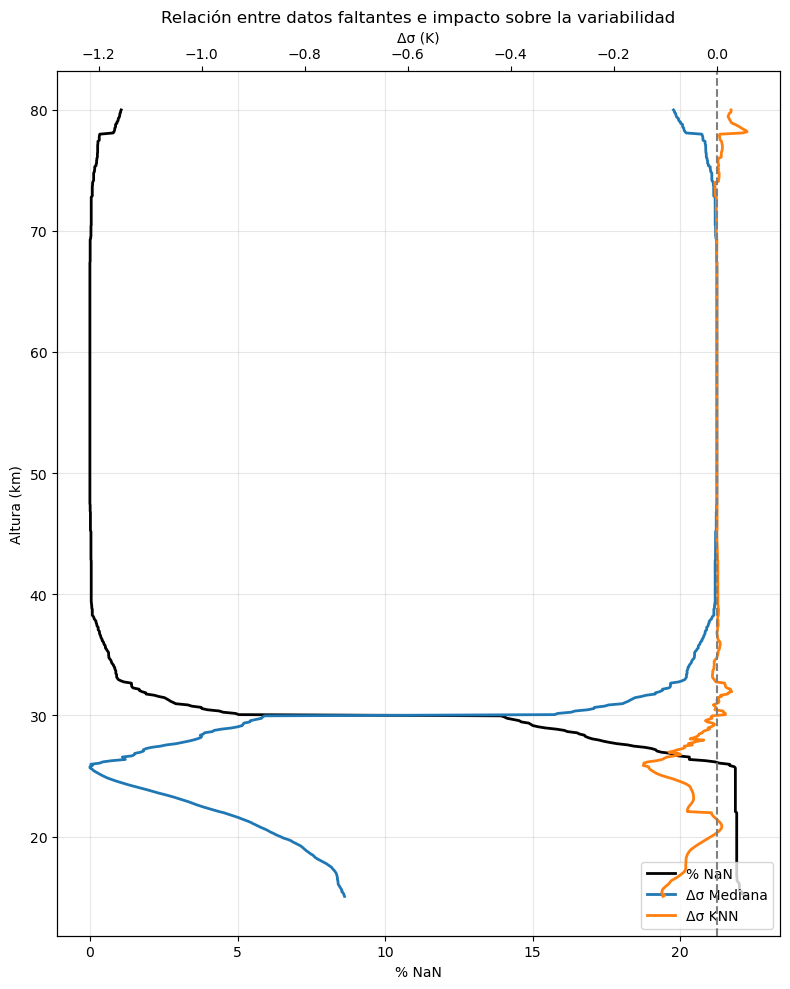

Máximo Δσ Mediana: 25.8 km
Máximo Δσ KNN: 25.9 km


In [20]:
# Vamos a superponer los % NaN y las diferencias σ - Mediana y σ - KNN

nan_por_altura = X_temp.isna().mean() * 100

diff_std_B = std_B - std_original
diff_std_C = std_C - std_original

fig, ax1 = plt.subplots(figsize=(8,10))

# ==========================
# Eje 1: % NaN
# ==========================

ax1.plot(
    nan_por_altura,
    alturas_km,
    color='black',
    linewidth=2,
    label='% NaN'
)

ax1.set_xlabel('% NaN')
ax1.set_ylabel('Altura (km)')
ax1.grid(alpha=0.3)

# ==========================
# Eje 2: Δσ
# ==========================

ax2 = ax1.twiny()

ax2.plot(
    diff_std_B,
    alturas_km,
    linewidth=2,
    label='Δσ Mediana'
)

ax2.plot(
    diff_std_C,
    alturas_km,
    linewidth=2,
    label='Δσ KNN'
)

ax2.axvline(
    0,
    color='gray',
    linestyle='--'
)

ax2.set_xlabel('Δσ (K)')

# ==========================
# Leyenda combinada
# ==========================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower right'
)

plt.title(
    'Relación entre datos faltantes e impacto sobre la variabilidad'
)

plt.tight_layout()
plt.show()

altura_max_mediana = alturas_km[np.abs(diff_std_B).argmax()]
altura_max_knn = alturas_km[np.abs(diff_std_C).argmax()]

print(f"Máximo Δσ Mediana: {altura_max_mediana:.1f} km")
print(f"Máximo Δσ KNN: {altura_max_knn:.1f} km")


In [21]:
# Exportación del imputador KNN

import joblib
from pathlib import Path

carpeta_modelo = Path("modelo_exportado")
carpeta_modelo.mkdir(exist_ok=True)

joblib.dump(
    imputer,
    carpeta_modelo / "knn_imputer_dataset_c.pkl"
)

archivo_imputer = carpeta_modelo / "knn_imputer_dataset_c.pkl"

print("Archivo guardado:", archivo_imputer.exists())
print("Ruta:", archivo_imputer.resolve())

Archivo guardado: True
Ruta: C:\Users\orlan\Documents\Aprendizaje Automatico\TP\modelo_exportado\knn_imputer_dataset_c.pkl
